In [1]:
import numpy as np
import camb
from matplotlib import pyplot as plt
from camb import model, initialpower

In [2]:
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.InitPower.set_params(ns=0.965, As=2e-9)
pars.set_matter_power(redshifts=[0., 2., 4.], kmax=2.0)

#Linear spectra
pars.NonLinear = model.NonLinear_none
results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)

#Non-Linear spectra (Halofit)
pars.NonLinear = model.NonLinear_both
results.calc_power_spectra(pars)
kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-4, maxkh=1, npoints = 200)
s8 = np.array(results.get_sigma8())

Note: redshifts have been re-sorted (earliest first)


In [3]:
s8

array([0.20356037, 0.33503914, 0.80260802])

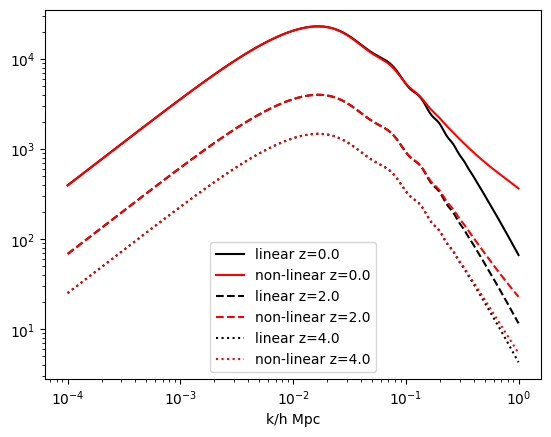

In [4]:
for i, (redshift, line) in enumerate(zip(z,['-','--', ":"])):
    plt.loglog(kh, pk[i,:], color='k', ls = line, label='linear z=%s'%redshift)
    plt.loglog(kh_nonlin, pk_nonlin[i,:], color='r', ls = line, label='non-linear z=%s'%redshift)
plt.xlabel('k/h Mpc')
plt.legend()

0.17949657528339408 1e-10
0.319195063998961 3.1622776601683795e-10
0.5676180100954086 1e-09
1.009383420119931 3.1622776601683795e-09
1.7949657528339404 1e-08


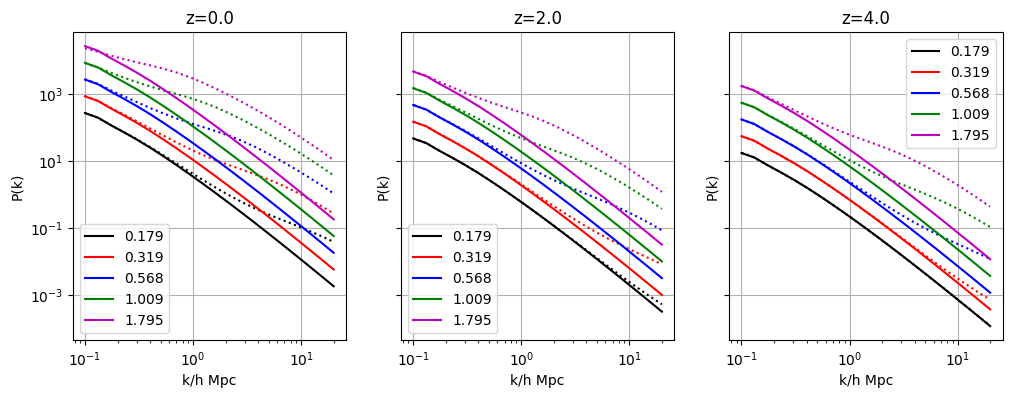

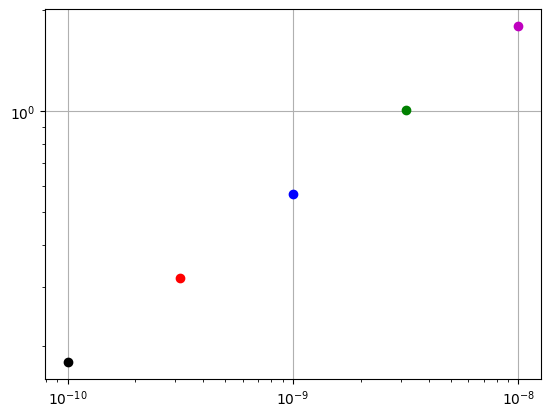

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, num=0)
colors = ['k', 'r', 'b', 'g', 'm']
As_vals = np.logspace(-10, -8, 5)
for As, color in zip(As_vals, colors):
    pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
    pars.InitPower.set_params(ns=0.965, As=As)
    pars.set_matter_power(redshifts=[4., 2., 0.], kmax=100.0)

    pars.NonLinear = model.NonLinear_none
    results = camb.get_results(pars)
    kh, z, pk = results.get_matter_power_spectrum(minkh=1e-1, maxkh=2e1, npoints = 20)
    s8 = np.array(results.get_sigma8())[-1]
    print(s8, As)
    plt.figure(1)
    plt.plot(As, s8, 'o', color=color)
    plt.loglog()
    plt.grid()

    pars.NonLinear = model.NonLinear_both
    results.calc_power_spectra(pars)
    kh_nonlin, z_nonlin, pk_nonlin = results.get_matter_power_spectrum(minkh=1e-1, maxkh=2e1, npoints = 20)

    for i in range(3):
        axs[i].loglog(kh, pk[i,:], label=f"{s8:.3f}", color=color)
        axs[i].loglog(kh_nonlin, pk_nonlin[i,:], ls=":", color=color)
        axs[i].set_xlabel('k/h Mpc')
        axs[i].set_ylabel('P(k)')
        axs[i].set_title(f"z={z[i]}")
        axs[i].legend()
        axs[i].grid()

plt.show()
plt.close('all')